In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
df = pd.read_csv('../dataset/spam.csv', encoding='latin-1')

In [18]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [19]:
df.shape

(5572, 5)

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [21]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [22]:
df=df[['v1','v2']] #removing the unnecessary columns

In [23]:
df.columns =['label','message']  #renaming the columns to label and message

In [24]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [25]:
df.duplicated().sum()  #checking for duplicate values

np.int64(403)

In [26]:
df= df.drop_duplicates() #removig the duplicate values

In [27]:
df.shape

(5169, 2)

In [28]:
df['label'].value_counts()  # checking the distribution

label
ham     4516
spam     653
Name: count, dtype: int64

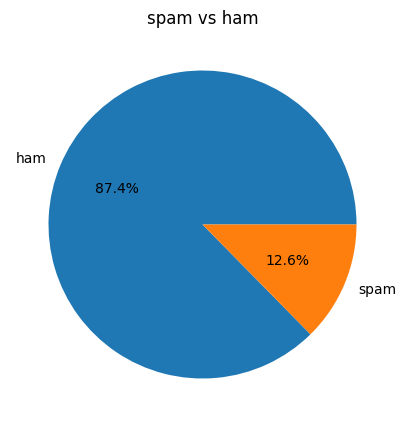

In [29]:
plt.figure(figsize=(8,5))
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'  # 
    )
plt.title('spam vs ham')
plt.ylabel("")
plt.show()

In [31]:
import nltk #natural language toolkit . computer understanding human language

nltk.download('punkt') #tokenization
nltk.download('punkt_tab')
nltk.download('stopwords') #not carrying any meaning to the text

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [34]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer  #convertinng word in rootform
from nltk.tokenize import word_tokenize

import string

In [35]:
ps=PorterStemmer() #making object of stemmer

In [33]:
def transform_text(text):

    # Lowercase
    text = text.lower()

    # Tokenize
    words = word_tokenize(text)

    cleaned = []

    # Keep only alphanumeric words
    for word in words:
        if word.isalnum():
            cleaned.append(word)

    words = cleaned
    cleaned = []

    # Remove stopwords and punctuation
    for word in words:
        if word not in stopwords.words('english') and word not in string.punctuation:
            cleaned.append(word)

    words = cleaned
    cleaned = []

    # Stemming
    for word in words:
        cleaned.append(ps.stem(word))

    return " ".join(cleaned)

In [ ]:
sample = "Congratulations!! You have WON $5000. Click here now!"

print(transform_text(sample)) 

congratul 5000 click


 # here what actually happening is at first text is passed to the function then .lower() change the text into lowercase, then tokenizer change the text into tokenized words, then we add only alphanumeric words to cleaned(just keep important world only). then we remove stopwords(e.g you,the,have ,here,now etc.these donot carry any importance meaning to the text).we also remove the punctiuation marks and finally do stemming,which means changing words into in root form .. then return by using join () which convert tokenize words back to text /sentence.

In [ ]:
df['transformed_text'] = df['message'].apply(transform_text) #creating new columns transformed_text , saving all the message into it in the above form using transform_text function.

In [38]:
df[["message",'transformed_text']].head()

,message,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [39]:
df[['label', 'message', 'transformed_text']].head()

,label,message,transformed_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


TF-IDF Vectorization => it converts every cleaned message into a numerical feature vector while giving more importance to the informative words and lower importance to very common words.we use it because logistic regression only understand numeric value.

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(max_features=3000) 


# here we creating the object of tfidf to use  TfidfVectorizer and we are  not using all the words , just keeping 3000 most informative words , which reduce memory usagge and speeds up training.

In [ ]:
X = tfidf.fit_transform(df['transformed_text']).toarray()


# here X is input feature we will give to model . here using tfidf were converting all the input feature number first. here fit keyword learn all the vocabulary and idf scores. the idf scores is the scores which tell which word is more importante, higher the score ,more will be priority.and .toarray() convert that automatic sparse matrix into regular numpy matrix.

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y= encoder.fit_transform(df['label'])



# here  what features which  tell whether the email is spam or not . We are converting into number because input X are also in number . label contains ham and spam keywords we are converting them into 0 and 1 using encoder.where ham->0 and spam ->1

In [ ]:
print(y[:10]) # verifyng our labeling.

[0 0 1 0 0 1 0 0 1 1]


In [ ]:
print(X.shape) # priting shapes 
print(y.shape)

(5169, 3000)
(5169,)


Spliting the data into training and testing part using train_test_split.

In [48]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# here 0.2 means we are using the 20 % data for testing and 80% data for traininig phase. here random_state used to get same train/split ,which makes the esperiments consistent. interestingly 42 number is used here .ha ha , we can use any number . but there is special story behinds  number 42..

In [50]:
#veryfying where the data splited correctly or not
print(X_train.shape)
print(X_test.shape)

(4135, 3000)
(1034, 3000)


Now time to use Logistic regression and training  data.

In [57]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(  class_weight='balanced',max_iter=1000,random_state=42) # this means train the data 1000 times which gives optimized results to find the best weights.

model.fit(X_train, y_train) # feeding data to model and training it..

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [58]:
y_pred = model.predict(X_test)  # contains model's predicted labels on the unseen data or in testing data.

In [59]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
#doing the evaluation of the model ,checkin how efficient it is.

In [60]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)

Accuracy : 0.9671179883945842
Precision: 0.8627450980392157
Recall   : 0.9103448275862069
F1 Score : 0.8859060402684564
[[868  21]
 [ 13 132]]


taking sample inputs and checking our model predecting correclty or not.

In [71]:
sample = """
Your bank account has been suspended.

Verify your account immediately by clicking the link below.
"""

In [72]:
cleaned = transform_text(sample)
print(cleaned)

bank account suspend verifi account immedi click link


In [73]:
vector = tfidf.transform([cleaned])

In [74]:
prediction = model.predict(vector)

print(prediction)

[1]


In [75]:
if prediction[0] == 1:
    print("🚨 Spam")
else:
    print("✅ Ham")

🚨 Spam


In [ ]:
import joblib    # saving all the data so that i can use in backen and fronted

joblib.dump(model, "../models/spam_model.pkl")
joblib.dump(tfidf, "../models/vectorizer.pkl")
joblib.dump(encoder, "../models/label_encoder.pkl")


['../models/label_encoder.pkl']